# Under-sampling and Feature Selection Pipeline
This notebook loads `datasets/BaseDataset.csv`, removes duplicates, tries two pipeline orders, and saves 3 final CSV files for top 9, 12, and 21 features.

# Imports

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.under_sampling import RandomUnderSampler

## Configuration

In [10]:
DATA_PATH = Path("../BaseDataset.csv")
OUTPUT_DIR = Path("")
TARGET_COL = "Diabetes_012"
TOP_K_VALUES = [9, 12, 21]
SCORING = "f1_macro"
CV_SPLITS = 5

## Load Dataset

In [11]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Original shape: {df.shape}")

Original shape: (253680, 22)


## Remove duplicates

In [12]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"New shape: {df.shape}")

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found in dataset columns.")

print("\nClass distribution after de-duplication:")
print(df[TARGET_COL].value_counts().sort_index())

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

Duplicates removed: 23899
New shape: (229781, 22)

Class distribution after de-duplication:
Diabetes_012
0.0    190055
1.0      4629
2.0     35097
Name: count, dtype: int64


## Split

In [13]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(160846, 21) (22978, 21) (45957, 21)


## Side-by-Side: Feature Selection First vs Under-Sampling First

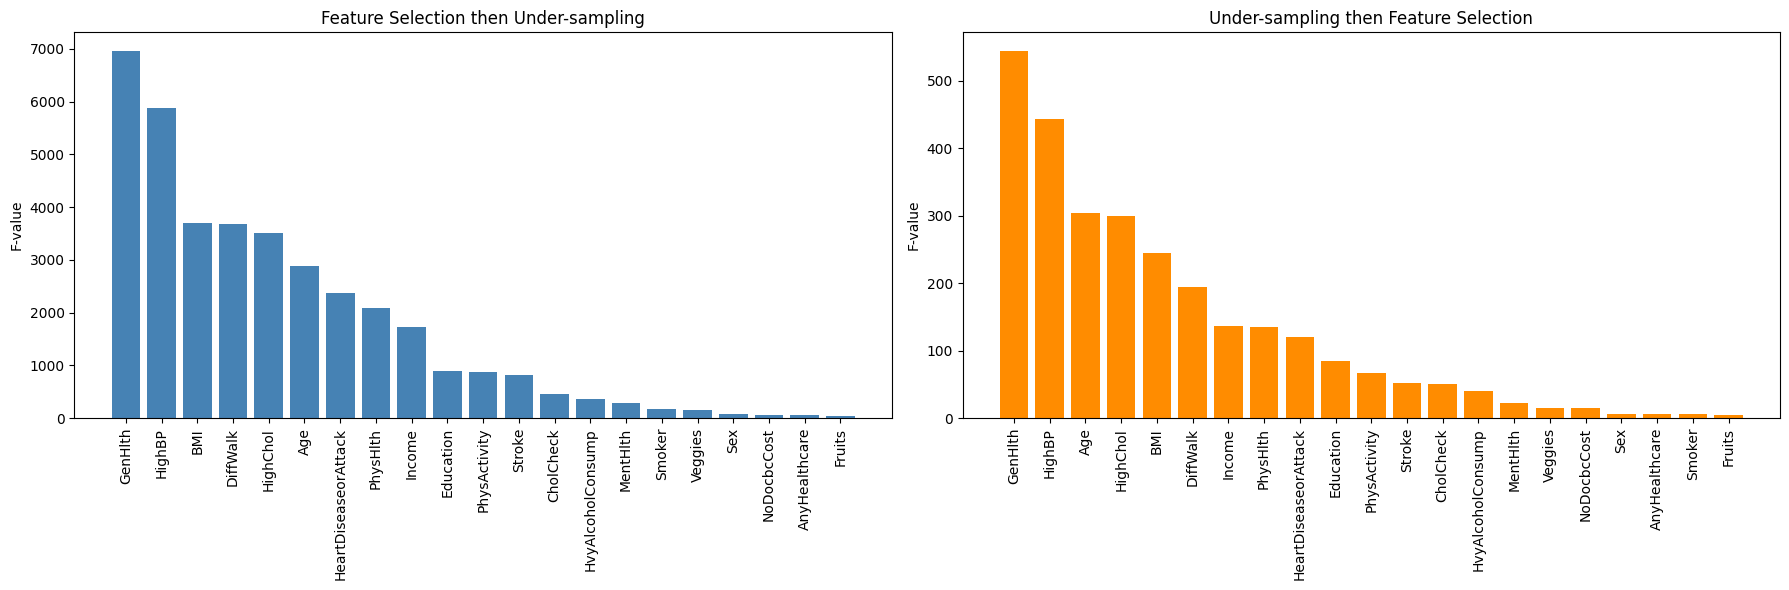

In [14]:
# Left plot: Feature selection on original training data
selector_all = SelectKBest(score_func=f_classif, k="all")
selector_all.fit(X_train, y_train)
scores = selector_all.scores_
features = X_train.columns
indices = np.argsort(scores)[::-1]

# Right plot: Under-sample first, then feature selection
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
selector_all_under = SelectKBest(score_func=f_classif, k="all")
selector_all_under.fit(X_train_under, y_train_under)
scores_under = selector_all_under.scores_
features_under = X_train_under.columns
indices_under = np.argsort(scores_under)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

axes[0].bar(range(len(scores)), scores[indices], color="steelblue")
axes[0].set_xticks(range(len(scores)))
axes[0].set_xticklabels(features[indices], rotation=90)
axes[0].set_title("Feature Selection then Under-sampling")
axes[0].set_ylabel("F-value")

axes[1].bar(range(len(scores_under)), scores_under[indices_under], color="darkorange")
axes[1].set_xticks(range(len(scores_under)))
axes[1].set_xticklabels(features_under[indices_under], rotation=90)
axes[1].set_title("Under-sampling then Feature Selection")
axes[1].set_ylabel("F-value")

plt.tight_layout()
plt.show()

## Save CSVs: Feature Selection First (k=9,12,21)

In [15]:
# Apply feature selection first, then under-sampling, and save 3 CSV files
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_files = []
for k in [9, 12, 21]:
    selector_k = SelectKBest(score_func=f_classif, k=k)
    X_k = selector_k.fit_transform(X, y)
    selected_cols = X.columns[selector_k.get_support()]
    X_k = pd.DataFrame(X_k, columns=selected_cols)

    rus_k = RandomUnderSampler(random_state=42)
    X_k_under, y_k_under = rus_k.fit_resample(X_k, y)

    out_df = X_k_under.copy()
    out_df[TARGET_COL] = y_k_under.values

    out_path = OUTPUT_DIR / f"undersampling_k{k}.csv"
    out_df.to_csv(out_path, index=False)
    saved_files.append((str(out_path), out_df.shape))

print("Saved files with shapes:")
for file_path, shape in saved_files:
    print(f"- {file_path}: {shape}")

Saved files with shapes:
- undersampling_k9.csv: (13887, 10)
- undersampling_k12.csv: (13887, 13)
- undersampling_k21.csv: (13887, 22)
